# 05 — Machine Learning Models

## Objective

In this notebook, we implement machine learning models for forecasting the Hourly Ontario Energy Price (HOEP).

Unlike classical statistical models, machine learning models rely on explicit feature engineering to capture temporal dependencies, seasonal patterns, and external market drivers.

The feature set was designed based on earlier analysis and includes:

- short-term lag features
- daily and weekly lag features
- rolling statistics
- calendar variables
- exogenous variables such as demand and generation

A direct forecasting strategy is used. Separate models are trained for:

- 1-step ahead forecasting
- 2-step ahead forecasting
- 3-step ahead forecasting

Hyperparameters are selected using the validation set, and final performance is evaluated on the test set using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

To assess temporal stability, the test set is also divided into four chronological segments.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

## Helper Functions


In [2]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)


def save_model_artifact(model, model_name, horizon):
    model_path = models_dir / f"{model_name}_h{horizon}.joblib"
    joblib.dump(model, model_path)
    return model_path


def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


def evaluate_by_chunk(y_true, y_pred, model_name, horizon, n_chunks=4):
    y_true_chunks = np.array_split(np.asarray(y_true), n_chunks)
    y_pred_chunks = np.array_split(np.asarray(y_pred), n_chunks)

    rows = []
    for i, (true_chunk, pred_chunk) in enumerate(zip(y_true_chunks, y_pred_chunks), start=1):
        mae, rmse = evaluate(true_chunk, pred_chunk)
        rows.append({
            "model": model_name,
            "horizon": horizon,
            "test_chunk": i,
            "mae": mae,
            "rmse": rmse
        })
    return pd.DataFrame(rows)


def print_dataset_shapes(X_train, X_val, X_test, y_train, y_val, y_test, horizon):
    print(f"===== Horizon {horizon} =====")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
    print("X_test :", X_test.shape,  "y_test :", y_test.shape)
    print()

def plot_predictions(y_true, preds_dict, horizon, start_idx= None, end_idx= None):
    plt.figure(figsize=(12, 5))
    plt.plot(np.asarray(y_true)[start_idx:end_idx], label="Actual", linewidth=2)

    for model_name, pred in preds_dict.items():
        plt.plot(np.asarray(pred)[start_idx:end_idx], label=model_name, alpha=0.8)

    plt.title(f"Forecast vs Actual — Horizon {horizon}")
    plt.xlabel("Time Index")
    plt.ylabel("HOEP")
    plt.legend()
    plt.grid(True)
    plt.show()

## Load Horizon-Specific Datasets

The model-ready machine learning datasets were created in Notebook 3 and saved separately for each forecast horizon.

This allows direct forecasting, where each horizon has its own independent feature matrix and target series.

In [3]:
ml_dir = Path("../data/processed/ml_dir")

def drop_missing_xy(X, y):
    mask = X.notna().all(axis=1) & y.notna()
    X_clean = X.loc[mask].reset_index(drop=True)
    y_clean = y.loc[mask].reset_index(drop=True)
    return X_clean, y_clean

def load_ml_data(horizon):
    X_train = pd.read_parquet(ml_dir / f"X_train_h{horizon}.parquet")
    X_val   = pd.read_parquet(ml_dir / f"X_val_h{horizon}.parquet")
    X_test  = pd.read_parquet(ml_dir / f"X_test_h{horizon}.parquet")

    y_train = pd.read_parquet(ml_dir / f"y_train_h{horizon}.parquet")["hoep"]
    y_val   = pd.read_parquet(ml_dir / f"y_val_h{horizon}.parquet")["hoep"]
    y_test  = pd.read_parquet(ml_dir / f"y_test_h{horizon}.parquet")["hoep"]

    
    X_train, y_train = drop_missing_xy(X_train, y_train)
    X_val, y_val = drop_missing_xy(X_val, y_val)
    X_test, y_test = drop_missing_xy(X_test, y_test)
    

    return X_train, X_val, X_test, y_train, y_val, y_test

In [4]:
# Quick sanity check 
for h in [1, 2, 3]:
    X_train, X_val, X_test, y_train, y_val, y_test = load_ml_data(h)
    print_dataset_shapes(X_train, X_val, X_test, y_train, y_val, y_test, h)

===== Horizon 1 =====
X_train: (17376, 21) y_train: (17376,)
X_val  : (2159, 21) y_val  : (2159,)
X_test : (719, 21) y_test : (719,)

===== Horizon 2 =====
X_train: (17375, 21) y_train: (17375,)
X_val  : (2158, 21) y_val  : (2158,)
X_test : (718, 21) y_test : (718,)

===== Horizon 3 =====
X_train: (17374, 21) y_train: (17374,)
X_val  : (2157, 21) y_val  : (2157,)
X_test : (717, 21) y_test : (717,)



In [5]:
#Check Feature names
X_train_h1, X_val_h1, X_test_h1, y_train_h1, y_val_h1, y_test_h1 = load_ml_data(1)
feature_names = X_train_h1.columns.tolist()
feature_names


['lag_1',
 'lag_2',
 'lag_3',
 'lag_24',
 'lag_168',
 'rolling_mean_24',
 'rolling_std_24',
 'rolling_mean_168',
 'hour_t_plus_1',
 'day_of_week_t_plus_1',
 'is_weekend_t_plus_1',
 'month_t_plus_1',
 'season_t_plus_1',
 'market_demand',
 'ontario_demand',
 'nuclear',
 'gas',
 'hydro',
 'wind',
 'solar',
 'biofuel']

## Linear Regression Baseline

Linear Regression is used as the first machine learning baseline.

Because linear regression is sensitive to feature scales, the inputs are standardized using `StandardScaler`. The scaler is fit only on the training data during validation, and then refit on the combined training and validation data for final test evaluation.

In [6]:
lr_results = []
lr_weekly_rows = []
lr_models = {}

for h in [1, 2, 3]:
    X_train, X_val, X_test, y_train, y_val, y_test = load_ml_data(h)

    # Validation-stage model
    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    lr_pipeline.fit(X_train, y_train)

    val_pred = lr_pipeline.predict(X_val)
    val_mae, val_rmse = evaluate(y_val, val_pred)

    # Final model on train + val
    X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    final_lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])
    final_lr_pipeline.fit(X_train_val, y_train_val)

    test_pred = final_lr_pipeline.predict(X_test)
    
    test_mae, test_rmse = evaluate(y_test, test_pred)

    lr_results.append({
        "model": "LinearRegression",
        "horizon": h,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse
    })

    lr_models[h] = final_lr_pipeline
    save_model_artifact(final_lr_pipeline, "linear_regression", h)

    weekly_df = evaluate_by_chunk(y_test, test_pred, "LinearRegression", h)
    lr_weekly_rows.append(weekly_df)

lr_results_df = pd.DataFrame(lr_results)
lr_weekly_df = pd.concat(lr_weekly_rows, ignore_index=True)

lr_weekly_df

,model,horizon,test_chunk,mae,rmse
0,LinearRegression,1,1,22.501726,50.853207
1,LinearRegression,1,2,11.688473,26.661938
2,LinearRegression,1,3,12.634675,27.763816
3,LinearRegression,1,4,9.021574,15.764237
4,LinearRegression,2,1,26.824420,57.851975
5,LinearRegression,2,2,13.859739,30.908806
6,LinearRegression,2,3,15.574765,30.268535
7,LinearRegression,2,4,11.666026,19.083572
8,LinearRegression,3,1,28.085675,60.024505
9,LinearRegression,3,2,14.271886,32.072451


## Random Forest

Random Forest is a nonlinear ensemble model that can capture interactions and nonlinear relationships between lagged values, rolling statistics, calendar variables, and exogenous variables.

Hyperparameters are selected using the validation set.

In [7]:
# Random forest hyperparameter grid

rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.8]
}

In [8]:
rf_results = []
rf_weekly_rows = []
rf_models = {}
rf_tuning_tables = {}

for h in [1, 2, 3]:
    X_train, X_val, X_test, y_train, y_val, y_test = load_ml_data(h)

    best_rmse = float("inf")
    best_params = None
    tuning_rows = []

    for params in ParameterGrid(rf_param_grid):
        model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mae, val_rmse = evaluate(y_val, val_pred)

        row = {
            "horizon": h,
            **params,
            "val_mae": val_mae,
            "val_rmse": val_rmse
        }
        tuning_rows.append(row)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_params = params

    rf_tuning_tables[h] = pd.DataFrame(tuning_rows).sort_values("val_rmse").reset_index(drop=True)

    # Retrain on train + validation
    X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    final_model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_params
    )
    final_model.fit(X_train_val, y_train_val)

    test_pred = final_model.predict(X_test)
    test_mae, test_rmse = evaluate(y_test, test_pred)

    rf_results.append({
        "model": "RandomForest",
        "horizon": h,
        "best_params": str(best_params),
        "val_rmse_best": best_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse
    })

    rf_models[h] = final_model
    save_model_artifact(final_model, "random_forest", h)

    weekly_df = evaluate_by_chunk(y_test, test_pred, "RandomForest", h)
    rf_weekly_rows.append(weekly_df)

rf_results_df = pd.DataFrame(rf_results)
rf_weekly_df = pd.concat(rf_weekly_rows, ignore_index=True)

rf_results_df

,model,horizon,best_params,val_rmse_best,test_mae,test_rmse
0,RandomForest,1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",56.231669,13.426880,32.375813
1,RandomForest,2,"{'max_depth': None, 'max_features': 'sqrt', 'm...",60.125405,16.019711,36.282371
2,RandomForest,3,"{'max_depth': 12, 'max_features': 'sqrt', 'min...",61.935761,17.022131,37.740553


## XGBoost

XGBoost is the main machine learning model in this notebook.

It is particularly well suited for structured forecasting problems because it can model nonlinear relationships, interactions between variables, and complex effects of lagged and exogenous features.

Hyperparameters are selected using the validation set.

In [9]:
xgb_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

In [10]:
xgb_results = []
xgb_weekly_rows = []
xgb_models = {}
xgb_tuning_tables = {}

for h in [1, 2, 3]:
    X_train, X_val, X_test, y_train, y_val, y_test = load_ml_data(h)

    best_rmse = float("inf")
    best_params = None
    tuning_rows = []

    for params in ParameterGrid(xgb_param_grid):
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            **params
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mae, val_rmse = evaluate(y_val, val_pred)

        row = {
            "horizon": h,
            **params,
            "val_mae": val_mae,
            "val_rmse": val_rmse
        }
        tuning_rows.append(row)

        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_params = params

    xgb_tuning_tables[h] = pd.DataFrame(tuning_rows).sort_values("val_rmse").reset_index(drop=True)

    # Retrain on train + validation
    X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    final_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **best_params
    )
    final_model.fit(X_train_val, y_train_val)

    test_pred = final_model.predict(X_test)
    test_mae, test_rmse = evaluate(y_test, test_pred)

    xgb_results.append({
        "model": "XGBoost",
        "horizon": h,
        "best_params": str(best_params),
        "val_rmse_best": best_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse
    })

    xgb_models[h] = final_model
    save_model_artifact(final_model, "xgboost", h)

    weekly_df = evaluate_by_chunk(y_test, test_pred, "XGBoost", h)
    xgb_weekly_rows.append(weekly_df)

xgb_results_df = pd.DataFrame(xgb_results)
xgb_weekly_df = pd.concat(xgb_weekly_rows, ignore_index=True)

xgb_results_df

,model,horizon,best_params,val_rmse_best,test_mae,test_rmse
0,XGBoost,1,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",57.607687,15.009658,36.315390
1,XGBoost,2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",60.802415,16.580760,36.992377
2,XGBoost,3,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",61.766681,18.359193,38.221459


In [11]:
xgb_weekly_df

,model,horizon,test_chunk,mae,rmse
0,XGBoost,1,1,23.833254,56.611763
1,XGBoost,1,2,11.213489,25.709922
2,XGBoost,1,3,12.425564,25.285094
3,XGBoost,1,4,12.552674,27.693618
4,XGBoost,2,1,26.934682,58.285811
5,XGBoost,2,2,13.709515,29.758673
6,XGBoost,2,3,15.115820,29.865981
7,XGBoost,2,4,10.521220,17.038665
8,XGBoost,3,1,27.121466,58.772468
9,XGBoost,3,2,14.077205,31.612798


## Weekly comparison table

In [12]:
all_ml_weekly_df = pd.concat([
    lr_weekly_df,
    rf_weekly_df,
    xgb_weekly_df
], ignore_index=True)

# Pivot weekly RMSE
pivot = all_ml_weekly_df.pivot_table(
    index=["model", "horizon"],
    columns="test_chunk",
    values=["mae", "rmse"]
).round(3)

pivot.columns = pivot.columns.swaplevel(0, 1)

pivot = pivot.sort_index(axis=1)

pivot

test_chunk                     1               2               3          \
                             mae    rmse     mae    rmse     mae    rmse   
model            horizon                                                   
LinearRegression 1        22.502  50.853  11.688  26.662  12.635  27.764   
                 2        26.824  57.852  13.860  30.909  15.575  30.269   
                 3        28.086  60.025  14.272  32.072  16.474  30.960   
RandomForest     1        21.982  51.927  10.924  24.959  11.548  25.260   
                 2        25.611  57.188  13.061  29.410  14.409  28.699   
                 3        25.407  58.407  13.887  31.795  15.879  29.890   
XGBoost          1        23.833  56.612  11.213  25.710  12.426  25.285   
                 2        26.935  58.286  13.710  29.759  15.116  29.866   
                 3        27.121  58.772  14.077  31.613  17.518  30.808   

test_chunk                     4          
                             mae    rmse  
model            horizon                  
LinearRegression 1         9.022  15.764  
                 2        11.666  19.084  
                 3        12.526  20.114  
RandomForest     1         9.231  15.192  
                 2        10.961  17.271  
                 3        12.869  19.249  
XGBoost          1        12.553  27.694  
                 2        10.521  17.039  
                 3        14.671  20.729

## Comparative Forecast Visualization — Test Set (April 2025)

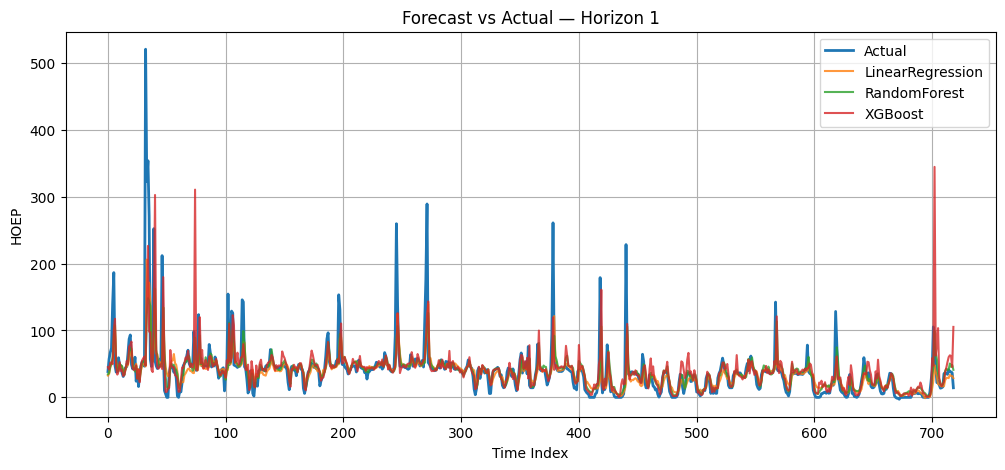

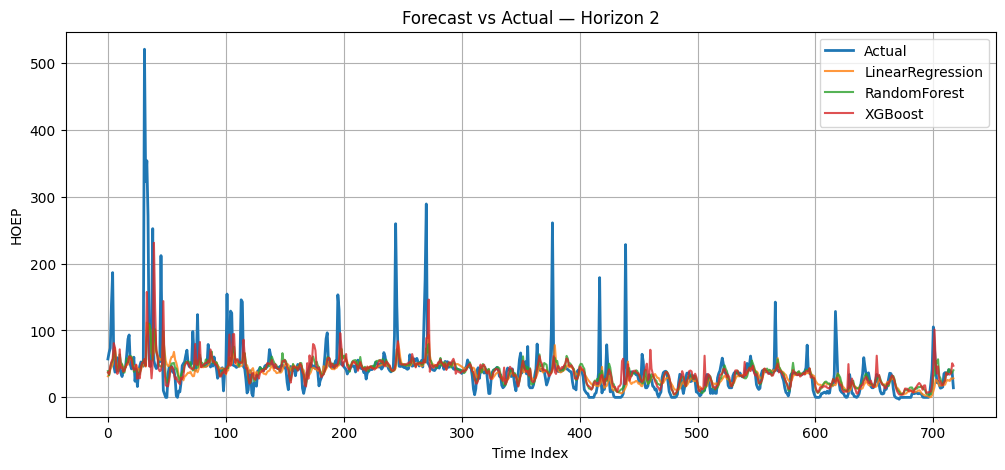

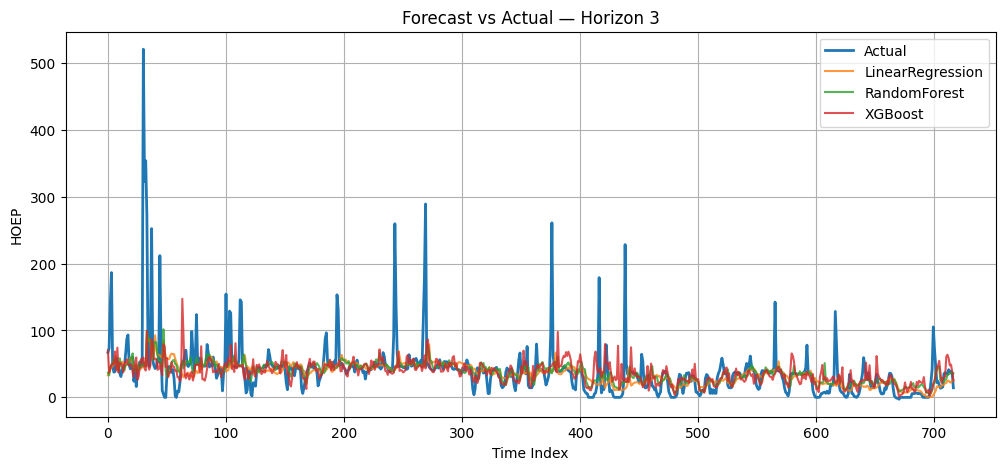

In [13]:
test_preds = {}

for h in [1, 2, 3]:
    X_train, X_val, X_test, y_train, y_val, y_test = load_ml_data(h)

    test_preds[h] = {
        "y_true"          : np.asarray(y_test),
        "LinearRegression": lr_models[h].predict(X_test),
        "RandomForest"    : rf_models[h].predict(X_test),
        "XGBoost"         : xgb_models[h].predict(X_test),
    }

# Step 2 — plot the full test set for each horizon
for h in [1, 2, 3]:
    plot_predictions(
        y_true=test_preds[h]["y_true"],
        preds_dict={
            "LinearRegression": test_preds[h]["LinearRegression"],
            "RandomForest"    : test_preds[h]["RandomForest"],
            "XGBoost"         : test_preds[h]["XGBoost"],
        },
        horizon=h
    )

    
